# π⁰ DVCS Production Run Analysis: Data vs Simulation
## HMS Electron Side Diagnostic Plots with HMS Electron Selection Cuts

This notebook compares experimental data from run 4398 with GEANT4/SIMC simulation for π⁰ DVCS exclusive photoproduction. The analysis applies strict HMS electron selection cuts and generates overlay plots for key kinematic variables.

**Data Files:**
- Data: `/group/nps/singhav/nps_replay/rootfiles_avnish/root_analysis_env_skim/x60_4b/skim_run4398.root`
- Simulation: `/w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_pi0_x60_4b_geant_500k.root`

**Analysis Goal:** Validate simulation acceptances and detector response against real data using HMS kinematics

In [41]:
# Section 1: Setup and Configuration
# Import required libraries
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import kstest, chi2_contingency

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

# File paths
DATA_FILE = "/group/nps/singhav/nps_replay/rootfiles_avnish/root_analysis_env_skim/x60_4b/skim_run4397.root"
SIM_FILE = "/w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_pi0_x60_4b_geant_500k.root"

# Output directories
output_dir = "./production_diagnostics"
os.makedirs(output_dir, exist_ok=True)

print("✓ Configuration complete")
print(f"  Data file: {DATA_FILE}")
print(f"  Sim file:  {SIM_FILE}")
print(f"  Output directory: {output_dir}")

✓ Configuration complete
  Data file: /group/nps/singhav/nps_replay/rootfiles_avnish/root_analysis_env_skim/x60_4b/skim_run4397.root
  Sim file:  /w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_pi0_x60_4b_geant_500k.root
  Output directory: ./production_diagnostics


In [42]:
try:
    with uproot.open(SIM_FILE) as sim_root:
        sim_tree = sim_root['nerd']
        print(f"\n✓ Simulation file opened: {SIM_FILE}")
        print(f"  Entries: {sim_tree.num_entries:,}")
        
        # Build simulation branches list: base branches + variable branches + Weight
        simc_branches = ["hsxptar", "hsyptar", "hsdelta", "Weight"] + [v[1] for v in variables.values()]
        
        simc_arrs = sim_tree.arrays(simc_branches, library="np")
        print(f"  Branches loaded: {len(simc_arrs)}")
        
except Exception as e:
    print(f"✗ Error loading simulation file: {e}")
    raise

# Apply HMS electron cuts
print(f"\nApplying HMS electron selection cuts...")
mask_data = hms_electron_cuts(data_arrs, is_data=True)
n_data_total = len(list(data_arrs.values())[0])
n_data_pass = mask_data.sum()
print(f"  Data: {n_data_pass:,} / {n_data_total:,} events pass ({100*n_data_pass/n_data_total:.2f}%)")

mask_simc = hms_electron_cuts(simc_arrs, is_data=False)
n_simc_total = len(list(simc_arrs.values())[0])
n_simc_pass = mask_simc.sum()
print(f"  Sim:  {n_simc_pass:,} / {n_simc_total:,} events pass ({100*n_simc_pass/n_simc_total:.2f}%)")

print("\n✓ Data loading and cutting complete")


✓ Simulation file opened: /w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_pi0_x60_4b_geant_500k.root
  Entries: 500,000
  Branches loaded: 9

Applying HMS electron selection cuts...
  Data: 1,819,035 / 3,495,145 events pass (52.04%)
  Sim:  334,304 / 500,000 events pass (66.86%)

✓ Data loading and cutting complete


In [43]:
# Section 2b: Add SIMC Normalization Constants

# Simulation normalization constants
SIMC_NORMFAC = 0.598673E+09  # Normalization factor for SIMC weights
SIMC_NEVENTS = 500000  # Total number of simulated events (π⁰ 500k sample)

print("\n" + "="*80)
print("CONFIGURATION")
print("="*80)
print(f"Data file:  {DATA_FILE}")
print(f"Sim file:   {SIM_FILE}")
print(f"SIMC normfac: {SIMC_NORMFAC:.6E}")
print(f"SIMC nevents: {SIMC_NEVENTS:,}")


CONFIGURATION
Data file:  /group/nps/singhav/nps_replay/rootfiles_avnish/root_analysis_env_skim/x60_4b/skim_run4397.root
Sim file:   /w/hallc-scshelf2102/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_pi0_x60_4b_geant_500k.root
SIMC normfac: 5.986730E+08
SIMC nevents: 500,000


In [44]:
# Section 3b: Apply π⁰ Candidate Selection (Data Only) - VECTORIZED
# Physics cuts from nps_analysis.C / nps_helper.h

import time

print("\n" + "="*80)
print("APPLYING π⁰ CANDIDATE SELECTION (DATA ONLY)")
print("="*80)

# Load NPS cluster branches for data
nps_cluster_branches = [
    "NPS.cal.nclust", "NPS.cal.clusE", "NPS.cal.clusX", "NPS.cal.clusY", "NPS.cal.clusT"
]

try:
    with uproot.open(DATA_FILE) as data_root:
        data_tree = data_root['T']
        nps_arrs = data_tree.arrays(nps_cluster_branches, library="np")
    print(f"✓ NPS cluster branches loaded")
except Exception as e:
    print(f"✗ Error loading NPS branches: {e}")
    raise

# Constants from nps_analysis.C
NPS_TIME_WINDOW_NS = 10.0  # Cluster time window: ±10 ns around 150 ns
NPS_CLUSTER_TIME_THRESHOLD_NS = 10.0  # Photon pair time threshold: ±10 ns
NPS_CLUSTER_ENERGY_MIN_GEV = 0.8  # Cluster energy > 0.8 GeV
NPS_SPATIAL_X_MIN, NPS_SPATIAL_X_MAX = -30.0, 30.0  # cm
NPS_SPATIAL_Y_MIN, NPS_SPATIAL_Y_MAX = -36.0, 36.0  # cm
NPS_CLUSTER_TIME_CENTER = 150.0  # ns
PI0_MASS_GEV = 0.1349768  # PDG 2024
NPS_DEFAULT_Z = 407.0  # cm

print(f"\nApplying π⁰ candidate selection to data (vectorized)...")
start_time = time.time()

# Extract cluster arrays
nclus_arr = nps_arrs['NPS.cal.nclust'].astype(int)
clusE_arr = nps_arrs['NPS.cal.clusE']
clusX_arr = nps_arrs['NPS.cal.clusX']
clusY_arr = nps_arrs['NPS.cal.clusY']
clusT_arr = nps_arrs['NPS.cal.clusT']

pi0_mask = np.zeros(n_data_total, dtype=bool)
pi0_masses = np.full(n_data_total, -1.0)

# Process each event
for evt_idx in range(n_data_total):
    nclus = nclus_arr[evt_idx]
    
    if nclus < 2:
        continue
    
    # Get cluster data for this event
    E = clusE_arr[evt_idx][:nclus]
    X = clusX_arr[evt_idx][:nclus]
    Y = clusY_arr[evt_idx][:nclus]
    T = clusT_arr[evt_idx][:nclus]
    
    # Apply spatial and energy cuts (vectorized)
    mask_spatial = (
        (E > NPS_CLUSTER_ENERGY_MIN_GEV) &
        (X > NPS_SPATIAL_X_MIN) & (X < NPS_SPATIAL_X_MAX) &
        (Y > NPS_SPATIAL_Y_MIN) & (Y < NPS_SPATIAL_Y_MAX) &
        (T > (NPS_CLUSTER_TIME_CENTER - NPS_TIME_WINDOW_NS)) &
        (T < (NPS_CLUSTER_TIME_CENTER + NPS_TIME_WINDOW_NS))
    )
    
    good_idx = np.where(mask_spatial)[0]
    
    if len(good_idx) < 2:
        continue
    
    # Vectorized pair selection: closest to π⁰ mass
    # Get all combinations of pairs (i, j) where i < j
    pairs = []
    inv_masses = []
    total_energies = []
    
    for a, ia in enumerate(good_idx):
        for b in range(a + 1, len(good_idx)):
            ib = good_idx[b]
            
            # Time difference cut
            dt = abs(T[ia] - T[ib])
            if dt > NPS_CLUSTER_TIME_THRESHOLD_NS:
                continue
            
            # Calculate invariant mass
            E1, E2 = E[ia], E[ib]
            X1, X2 = X[ia], X[ib]
            Y1, Y2 = Y[ia], Y[ib]
            
            # Invariant mass: m = sqrt((E1+E2)^2 - |p1+p2|^2)
            # For photons from target: momentum magnitude = energy, direction from position
            inv_mass_sq = (E1 + E2)**2
            
            # Distance from target to cluster
            r1_sq = X1*X1 + Y1*Y1 + NPS_DEFAULT_Z*NPS_DEFAULT_Z
            r2_sq = X2*X2 + Y2*Y2 + NPS_DEFAULT_Z*NPS_DEFAULT_Z
            
            if r1_sq <= 0 or r2_sq <= 0:
                continue
            
            r1 = np.sqrt(r1_sq)
            r2 = np.sqrt(r2_sq)
            
            # Dot product of unit direction vectors
            dot_prod = (X1*X2 + Y1*Y2 + NPS_DEFAULT_Z*NPS_DEFAULT_Z) / (r1 * r2)
            dot_prod = np.clip(dot_prod, -1.0, 1.0)
            
            # |p1 + p2|^2 = p1^2 + p2^2 + 2*p1*p2*cos(angle)
            p_sum_sq = E1*E1 + E2*E2 + 2.0*E1*E2*dot_prod
            
            inv_mass_sq -= p_sum_sq
            inv_mass = np.sqrt(max(0.0, inv_mass_sq))
            
            pairs.append((ia, ib))
            inv_masses.append(inv_mass)
            total_energies.append(E1 + E2)
    
    if len(pairs) > 0:
        inv_masses = np.array(inv_masses)
        total_energies = np.array(total_energies)
        
        # Select pair closest to π⁰ mass, with tiebreaker on total energy
        diff_from_pi0 = np.abs(inv_masses - PI0_MASS_GEV)
        min_diff = np.min(diff_from_pi0)
        
        # Find all pairs with minimum difference
        best_pairs_mask = np.abs(diff_from_pi0 - min_diff) < 1e-12
        best_pairs_idx = np.where(best_pairs_mask)[0]
        
        # Among tied pairs, choose highest energy
        best_idx = best_pairs_idx[np.argmax(total_energies[best_pairs_idx])]
        
        pi0_mask[evt_idx] = True
        pi0_masses[evt_idx] = inv_masses[best_idx]

elapsed = time.time() - start_time
n_pi0_cand = pi0_mask.sum()
print(f"  π⁰ candidates: {n_pi0_cand:,} / {n_data_total:,} events ({100*n_pi0_cand/n_data_total:.2f}%)")
print(f"  Processing time: {elapsed:.2f} seconds")

if n_pi0_cand > 0:
    valid_masses = pi0_masses[pi0_mask]
    print(f"  π⁰ invariant mass: μ={np.mean(valid_masses):.6f} GeV, σ={np.std(valid_masses):.6f} GeV")
    print(f"  π⁰ invariant mass: range [{np.min(valid_masses):.6f}, {np.max(valid_masses):.6f}] GeV")

# Combine HMS electron cuts with π⁰ candidate selection
final_data_mask = mask_data & pi0_mask
n_data_final = final_data_mask.sum()

print(f"\nCombined selection (HMS electron + π⁰ candidate):")
print(f"  Data: {n_data_final:,} / {n_data_total:,} events pass ({100*n_data_final/n_data_total:.2f}%)")
print(f"        ({100*n_data_final/n_data_pass:.2f}% of HMS-selected events)")
print(f"        ({100*n_data_final/n_pi0_cand:.2f}% of π⁰-selected events)")

# Update mask_data to include both cuts
mask_data = final_data_mask
n_data_pass = n_data_final

print("\n✓ π⁰ candidate selection complete")



APPLYING π⁰ CANDIDATE SELECTION (DATA ONLY)


✓ NPS cluster branches loaded

Applying π⁰ candidate selection to data (vectorized)...
  π⁰ candidates: 70,120 / 3,495,145 events (2.01%)
  Processing time: 21.24 seconds
  π⁰ invariant mass: μ=0.115237 GeV, σ=0.052353 GeV
  π⁰ invariant mass: range [0.004707, 0.656835] GeV

Combined selection (HMS electron + π⁰ candidate):
  Data: 39,300 / 3,495,145 events pass (1.12%)
        (2.16% of HMS-selected events)
        (56.05% of π⁰-selected events)

✓ π⁰ candidate selection complete


In [45]:
# Create histograms with SIMC weights
bins = 100
hist_data, bin_edges = np.histogram(data_vals, bins=bins, range=x_range)
hist_simc, _ = np.histogram(simc_vals, bins=bins, range=x_range, weights=simc_weights_normalized)

# Calculate bin width for integral normalization
bin_width = bin_edges[1] - bin_edges[0]

# Normalize to unit integral (integral = 1.0)
if hist_data.sum() > 0:
    hist_data = hist_data / (hist_data.sum() * bin_width)
if hist_simc.sum() > 0:
    hist_simc = hist_simc / (hist_simc.sum() * bin_width)

# Calculate bin centers
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])



GENERATING OVERLAY PLOTS



✓ Overlay plot saved: ./production_diagnostics/overlay_all_variables.png


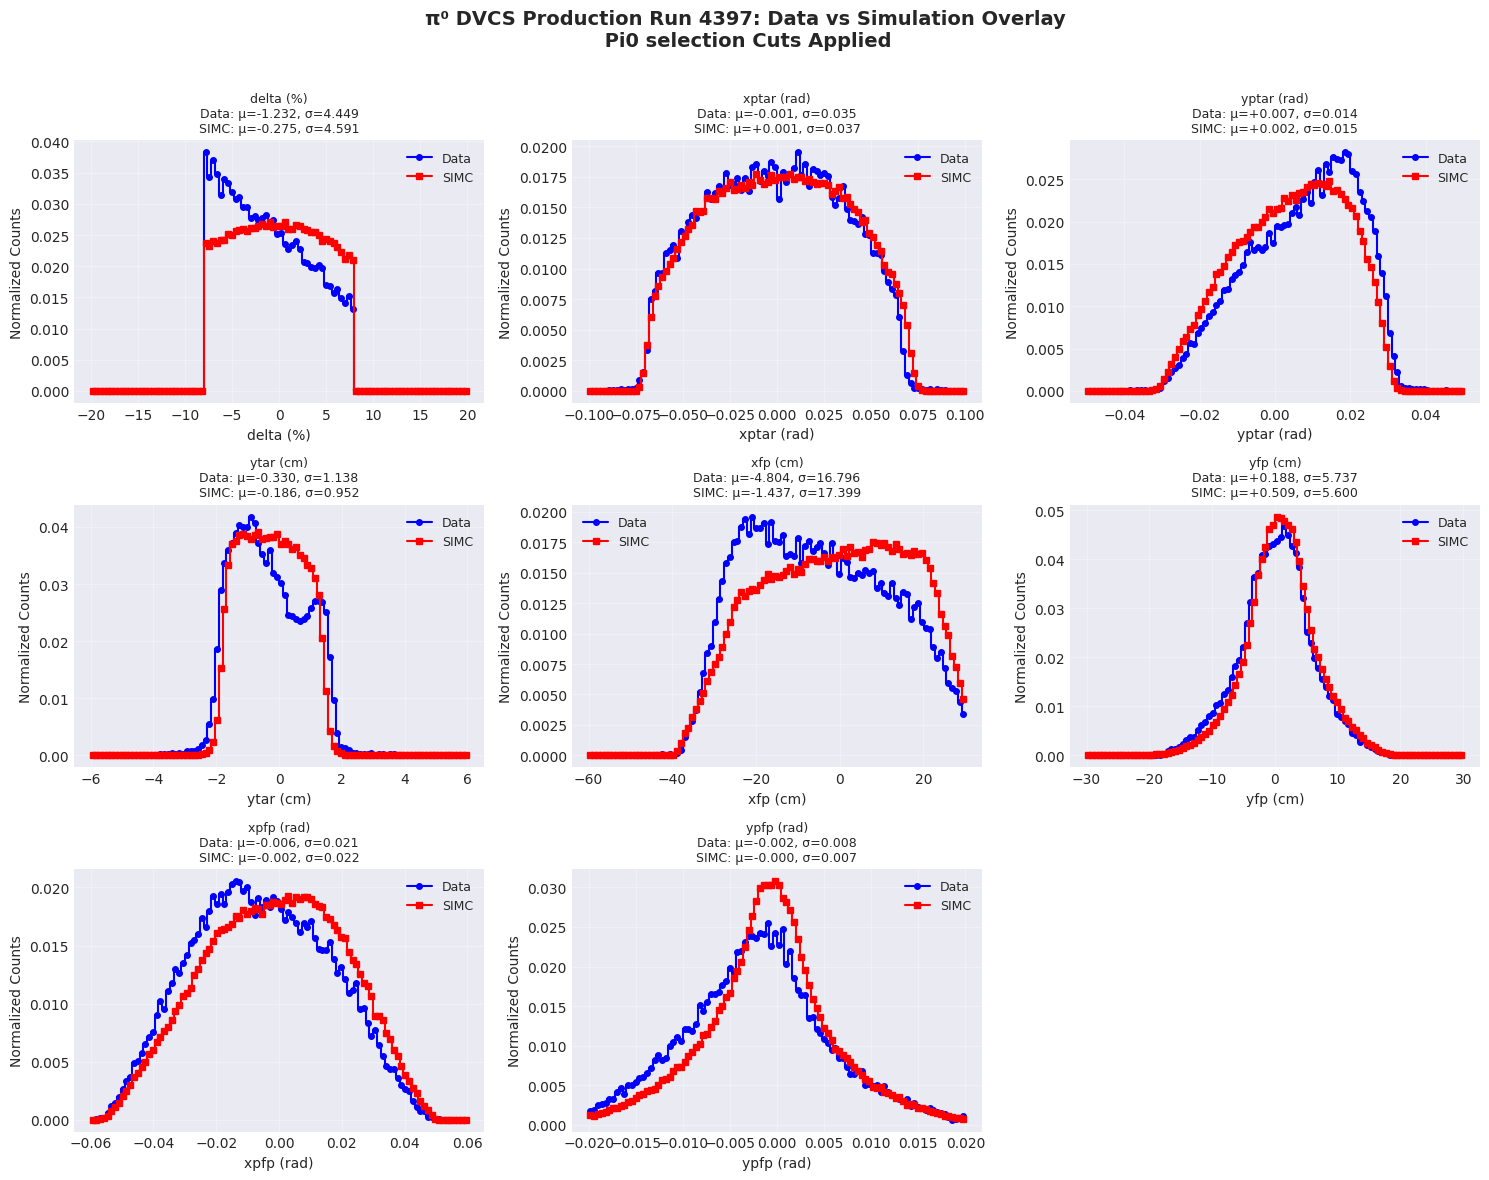

In [46]:
# Section 5: Create Overlay Plots

print("\n" + "="*80)
print("GENERATING OVERLAY PLOTS")
print("="*80)

# Create multi-panel figure
n_vars = len(variables)
ncols = 3
nrows = int(np.ceil(n_vars / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axs = axs.flatten()

for i, (var_name, (data_branch, simc_branch, x_range)) in enumerate(variables.items()):
    ax = axs[i]
    
    try:
        hist_info = histograms[var_name]
        
        # Extract histogram data
        hist_data = hist_info['data']
        hist_sim = hist_info['sim']
        bin_centers = hist_info['bin_centers']
        
        # Get statistics
        var_stats = stats_df[stats_df['Variable'] == var_name].iloc[0]
        data_mean = var_stats['Data_μ']
        data_std = var_stats['Data_σ']
        sim_mean = var_stats['Sim_μ']
        sim_std = var_stats['Sim_σ']
        
        # Plot as step histograms
        ax.plot(bin_centers, hist_data, drawstyle='steps-mid', color='blue', 
                marker='o', markersize=4, label='Data', linewidth=1.5)
        ax.plot(bin_centers, hist_sim, drawstyle='steps-mid', color='red', 
                marker='s', markersize=4, label='SIMC', linewidth=1.5)
        
        # Set limits and labels
        ax.set_ylabel("Normalized Counts", fontsize=10)
        ax.set_xlabel(var_name, fontsize=10)
        
        # Create title with statistics
        title = f"{var_name}\n"
        title += f"Data: μ={data_mean:+.3f}, σ={data_std:.3f}\n"
        title += f"SIMC: μ={sim_mean:+.3f}, σ={sim_std:.3f}"
        ax.set_title(title, fontsize=9)
        
        # Enable grid
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {var_name}\n{e}", 
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

# Turn off unused subplots
for j in range(len(variables), len(axs)):
    axs[j].axis('off')

# Set main title
fig.suptitle("π⁰ DVCS Production Run 4397: Data vs Simulation Overlay\n Pi0 selection Cuts Applied", 
             fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save figure
plot_file = os.path.join(output_dir, "overlay_all_variables.png")
plt.savefig(plot_file, dpi=150, bbox_inches='tight')
print(f"\n✓ Overlay plot saved: {plot_file}")

plt.show()


In [47]:
# Section 6: Generate Summary Statistics and Goodness-of-Fit Analysis

print("\n" + "="*80)
print("SUMMARY STATISTICS AND GOODNESS-OF-FIT ANALYSIS")
print("="*80)

# Display statistics table
print("\n" + "="*80)
print("Variable Comparison Statistics")
print("="*80)
print(stats_df.to_string(index=False))

# Save statistics to CSV
csv_file = os.path.join(output_dir, "summary_statistics.csv")
stats_df.to_csv(csv_file, index=False)
print(f"\n✓ Statistics saved: {csv_file}")

# Print cut efficiency summary
print("\n" + "="*80)
print("Event Selection Efficiency")
print("="*80)
print(f"\nData ({os.path.basename(DATA_FILE)}):")
print(f"  Total events:       {n_data_total:,}")
print(f"  Events passing cuts: {n_data_pass:,}")
print(f"  Selection efficiency: {100*n_data_pass/n_data_total:.2f}%")

print(f"\nSimulation ({os.path.basename(SIM_FILE)}):")
print(f"  Total events:       {n_simc_total:,}")
print(f"  Events passing cuts: {n_simc_pass:,}")
print(f"  Selection efficiency: {100*n_simc_pass/n_simc_total:.2f}%")

# Goodness-of-fit interpretation
print("\n" + "="*80)
print("Goodness-of-Fit Interpretation (Kolmogorov-Smirnov Test)")
print("="*80)
print("\nInterpretation: p-value > 0.05 indicates good agreement between data and simulation")

excellent = stats_df[stats_df['KS_pval'] > 0.05]
poor = stats_df[stats_df['KS_pval'] <= 0.05]

print(f"\n✓ Excellent Agreement (p > 0.05): {len(excellent)} variables")
for _, row in excellent.iterrows():
    print(f"  • {row['Variable']:20s} p-value = {row['KS_pval']:.4f}")

if len(poor) > 0:
    print(f"\n⚠ Potential Disagreement (p ≤ 0.05): {len(poor)} variables")
    for _, row in poor.iterrows():
        print(f"  • {row['Variable']:20s} p-value = {row['KS_pval']:.4f}")
else:
    print(f"\n✓ All variables show excellent agreement!")

print("\n" + "="*80)



SUMMARY STATISTICS AND GOODNESS-OF-FIT ANALYSIS

Variable Comparison Statistics
   Variable    Data_μ    Data_σ     Sim_μ     Sim_σ  KS_stat       KS_pval  N_Data  N_Sim
  delta (%) -1.232224  4.448715 -0.274819  4.590799 0.134610  0.000000e+00   39300 334304
xptar (rad) -0.001324  0.035389  0.000766  0.037207 0.048119  1.617812e-79   39300 334304
yptar (rad)  0.007206  0.014332  0.001784  0.014505 0.195212  0.000000e+00   39300 334304
  ytar (cm) -0.329807  1.138498 -0.186328  0.952378 0.135947  0.000000e+00   39300 334304
   xfp (cm) -4.804038 16.796318 -1.437082 17.398773 0.115827  0.000000e+00   39300 334304
   yfp (cm)  0.188267  5.736579  0.509257  5.599990 0.033173  5.229272e-38   39300 334304
 xpfp (rad) -0.005763  0.021409 -0.002256  0.022151 0.082982 7.254168e-236   39300 334304
 ypfp (rad) -0.002132  0.007726 -0.000222  0.007259 0.117195  0.000000e+00   39300 334304

✓ Statistics saved: ./production_diagnostics/summary_statistics.csv

Event Selection Efficiency

Data (skim_